In [4]:
# TÍTULO: Ingeniería de Datos - Recorte de Caracteres (TXT a Clasificación)
# OBJETIVO: Leer placas sintéticas y sus etiquetas TXT, recortar letras y organizar para YOLO Classify.

import os
import shutil
import cv2
import numpy as np
import string
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# --- RUTAS ---
PROJECT_ROOT = Path('../../')

# Origen: Salida del plate_generator.py
# Estructura esperada:
#   /images/*.jpg
#   /labels/*.txt (Formato: class_id x y w h)
SOURCE_PATH = PROJECT_ROOT / 'data' / 'processed' / '03_caracteres_sinteticos'

# Destino: Dataset final para entrenamiento de Clasificación
DEST_PATH = PROJECT_ROOT / 'datasets' / '03_caracteres'

# Mapeo de Clases (Debe coincidir con el generador)
# El generador usó: A-Z Sin I, O, Q (0-23), 0-9 (24-33) y '-' (34)
# Reconstruimos la lista para saber que el ID 0 es 'A', el 26 es '0', etc.
# CHARS = string.ascii_uppercase + string.digits + "-"
CHARS = "0123456789ABCDEFGHJKLMNPRSTUVWXYZ-"
ID_TO_CHAR = {i: c for i, c in enumerate(CHARS)}

print(f"Clases totales: {len(CHARS)}") # Debería imprimir 34
print("Entorno configurado.")

Clases totales: 34
Entorno configurado.


In [5]:
def process_txt_dataset(source_path, dest_path, test_size=0.2):
    img_dir = source_path / 'images'
    lbl_dir = source_path / 'labels'
    
    if not img_dir.exists() or not lbl_dir.exists():
        print(f"Error: No se encuentran las carpetas 'images' o 'labels' en {source_path}")
        return

    # 1. Limpiar destino
    if dest_path.exists():
        shutil.rmtree(dest_path)
    
    # Crear estructura train/val
    for split in ['train', 'val']:
        for char in CHARS:
            (dest_path / split / char).mkdir(parents=True, exist_ok=True)

    # 2. Listar imágenes
    image_files = list(img_dir.glob('*.jpg'))
    if not image_files:
        print("No se encontraron imágenes .jpg.")
        return

    # Dividir por placas (para no mezclar letras de la misma placa en train y val)
    train_files, val_files = train_test_split(image_files, test_size=test_size, random_state=42)
    
    print(f"Procesando {len(image_files)} placas...")
    
    # Contadores
    stats = {c: 0 for c in CHARS}

    def process_batch(files, split_name):
        for img_file in tqdm(files, desc=f"Split: {split_name}"):
            # Buscar TXT correspondiente
            txt_file = lbl_dir / f"{img_file.stem}.txt"
            if not txt_file.exists(): continue

            # Cargar imagen
            img = cv2.imread(str(img_file))
            if img is None: continue
            h_img, w_img = img.shape[:2]

            # Leer anotaciones
            with open(txt_file, 'r') as f:
                lines = f.readlines()

            for idx, line in enumerate(lines):
                parts = line.strip().split()
                if len(parts) != 5: continue

                # Parsear línea YOLO: class x_center y_center width height
                class_id = int(parts[0])
                nx, ny, nw, nh = map(float, parts[1:])

                # Recuperar el carácter real (ej. 0 -> 'A')
                if class_id not in ID_TO_CHAR: continue
                char_name = ID_TO_CHAR[class_id]

                # Des-normalizar a píxeles
                # Coordenadas del centro
                cx, cy = nx * w_img, ny * h_img
                # Ancho y alto en píxeles
                w, h = nw * w_img, nh * h_img

                # Calcular esquinas (Top-Left, Bottom-Right)
                x1 = int(cx - w / 2)
                y1 = int(cy - h / 2)
                x2 = int(cx + w / 2)
                y2 = int(cy + h / 2)

                # Validar límites (Clamping)
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w_img, x2), min(h_img, y2)

                # Recortar (ROI)
                crop = img[y1:y2, x1:x2]
                
                # Guardar si el recorte es válido
                if crop.size > 0 and crop.shape[0] > 5 and crop.shape[1] > 5:
                    save_name = f"{img_file.stem}_{idx}.jpg"
                    save_path = dest_path / split_name / char_name / save_name
                    cv2.imwrite(str(save_path), crop)
                    stats[char_name] += 1

    # Ejecutar
    process_batch(train_files, 'train')
    process_batch(val_files, 'val')

    print("\nDataset de Clasificación Construido.")
    print(f"   Total de recortes generados: {sum(stats.values())}")
    # print(f"   Distribución: {stats}")

In [6]:
process_txt_dataset(SOURCE_PATH, DEST_PATH)

Procesando 30000 placas...


Split: train:   0%|          | 0/24000 [00:00<?, ?it/s]

Split: val:   0%|          | 0/6000 [00:00<?, ?it/s]


Dataset de Clasificación Construido.
   Total de recortes generados: 247880


Auditoría Visual (Muestreo aleatorio):


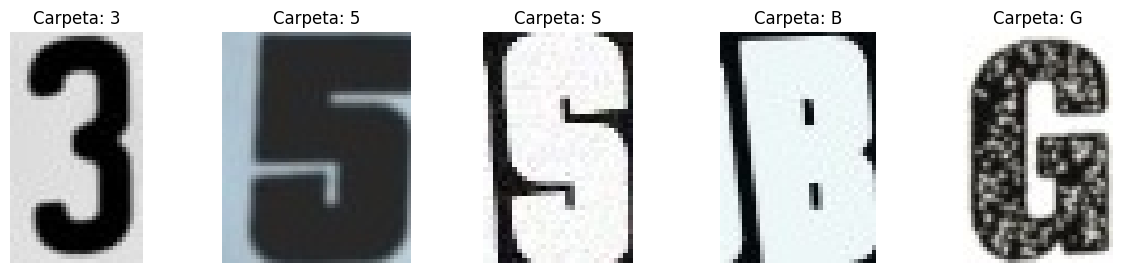

In [7]:
def audit_classification_dataset(path):
    train_path = path / 'train'
    if not train_path.exists(): return

    print("Auditoría Visual (Muestreo aleatorio):")
    
    # Seleccionar 5 clases al azar que tengan imágenes
    available_classes = [d.name for d in train_path.iterdir() if any(d.iterdir())]
    if not available_classes: return
    
    sample_classes = np.random.choice(available_classes, min(5, len(available_classes)), replace=False)

    plt.figure(figsize=(15, 3))
    for i, cls in enumerate(sample_classes):
        cls_dir = train_path / cls
        images = list(cls_dir.glob('*.jpg'))
        if not images: continue
        
        # Tomar una imagen
        img_path = np.random.choice(images)
        img = cv2.imread(str(img_path))
        
        plt.subplot(1, 5, i+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Carpeta: {cls}")
        plt.axis('off')
    plt.show()

audit_classification_dataset(DEST_PATH)

Auditoría Visual (Muestreo aleatorio):


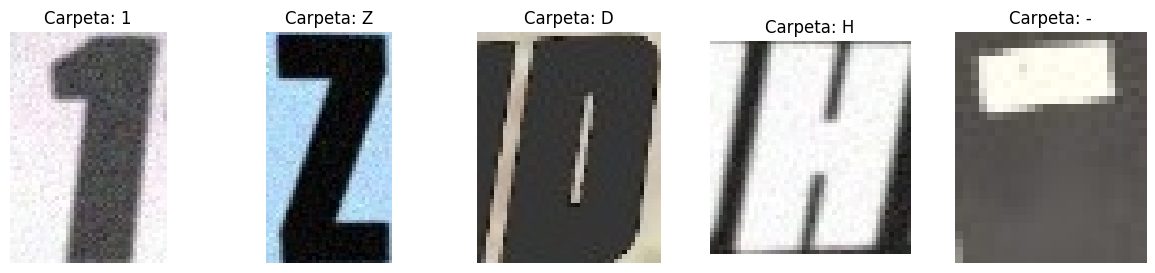

In [8]:
audit_classification_dataset(DEST_PATH)

Auditoría Visual (Muestreo aleatorio):


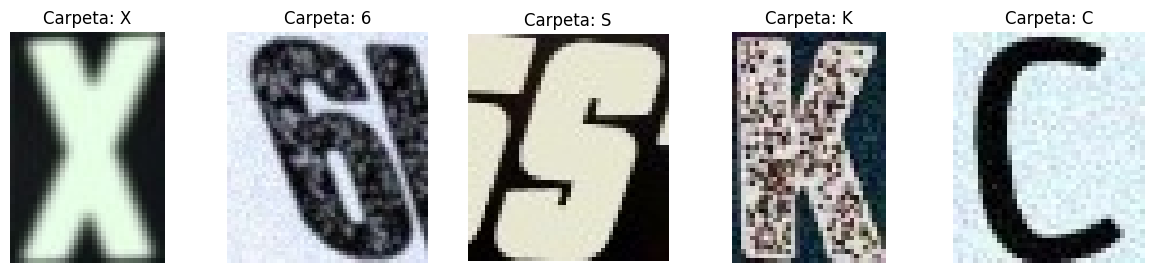

In [9]:
audit_classification_dataset(DEST_PATH)